In [77]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

reac5_iter18 = '/Users/aya/github/WWDR/BSM1-BSM2_MATLAB/BSM2_R2019b/BSM2_OutputDB/Morning_4hr/iter18/settler_data_DR_iteration_18.csv'
reac5_nominal18 = '/Users/aya/github/WWDR/BSM1-BSM2_MATLAB/BSM2_R2019b/BSM2_OutputDB/Morning_4hr/iter18/settler_data_nominal_iteration_18.csv'

# Step 1: Read CSVs
nominal = pd.read_csv(reac5_nominal18)
iteration = pd.read_csv(reac5_iter18)

# Step 2: Apply column labels
column_names = [
    "S_I", "S_S", "X_I", "X_S", "X_BH", "X_BA", "X_P",
    "S_O", "S_NO", "S_NH", "S_ND", "X_ND", "S_ALK", "TSS", "Q"
]
nominal.columns = column_names
iteration.columns = column_names

# Step 3: Define EQI constants
BSS = 2
BCOD = 1
BNKj = 30
BNO = 10
BBOD5 = 2
i_XB = 0.08
i_XP = 0.06

# Helper to compute EQI
def compute_eqi(df):
    SSe = df["TSS"]
    CODe = df["S_I"] + df["S_S"] + df["X_I"] + df["X_S"] + df["X_BH"] + df["X_BA"] + df["X_P"]
    SNKje = df["S_NH"] + df["S_ND"] + df["X_ND"] + i_XB * (df["X_BH"] + df["X_BA"]) + i_XP * (df["X_I"] + df["X_P"])
    SNOe = df["S_NO"]
    BOD5e = df["S_S"] + df["X_S"]  # BOD5 estimated as soluble + particulate
    EQIvecinst = (BSS * SSe + BCOD * CODe + BNKj * SNKje + BNO * SNOe + BBOD5 * BOD5e)
    return EQIvecinst

# Step 4: Add EQI series and moving average
for df in [nominal, iteration]:
    df["EQIvecinst"] = compute_eqi(df)
    df["mR"] = df["EQIvecinst"].rolling(window=96, min_periods=1).mean()
    df["tagS"] = 0
    df["tagF"] = 0

# Step 5: Compute TagS
def compute_tags(df):
    lhs = 4
    m = df["mR"][lhs:].mean()
    s = df["mR"][lhs:].std()
    for i in range(len(df)):
        val = df.at[i, "mR"]
        if val > m + 1.75 * s:
            df.at[i, "tagS"] = 3
        elif val > m + 1.5 * s:
            df.at[i, "tagS"] = 2
        elif val > m + s:
            df.at[i, "tagS"] = 1
        else:
            df.at[i, "tagS"] = 0

# Step 6: Compute TagF
def compute_tagF(df):
    for i in range(len(df)):
        s = df["tagS"]
        if i < 3:
            continue
        if s[i] == 3:
            if s[i-1] >= 1 and s[i-2] >= 1 and s[i-3] >= 1:
                df.at[i, "tagF"] = 3
            elif s[i-1] >= 1 and s[i-2] >= 1:
                df.at[i, "tagF"] = 2
            else:
                df.at[i, "tagF"] = 2
        elif s[i] == 2:
            if s[i-1] >= 1 and s[i-2] >= 1 and s[i-3] >= 1:
                df.at[i, "tagF"] = 3
            elif s[i-1] >= 1 and s[i-2] >= 1:
                df.at[i, "tagF"] = 2
            else:
                df.at[i, "tagF"] = 1
        elif s[i] == 1:
            if s[i-1] >= 1 and s[i-2] >= 1 and s[i-3] >= 1:
                df.at[i, "tagF"] = 2
            elif s[i-1] >= 1:
                df.at[i, "tagF"] = 1
            else:
                df.at[i, "tagF"] = 0
        else:
            df.at[i, "tagF"] = 0

# Step 7: Compute TagR
key_assignment = {
    (1.0, 2): 2,
    (3.0, 2): 3,
    (0.0, 0): 0,
    (3.0, 3): 3,
    (2.0, 1): 2,
    (2.0, 3): 3,
    (2.0, 2): 3,
    (1.0, 1): 1,
    (1.0, 0): 1,
    (1.0, 3): 2,
    (2.0, 0): 0,
    (3.0, 0): 2,
    (3.0, 1): 2
}

def find_key_for_tuple(tpl):
    for key_tpl, value in key_assignment.items():
        if (math.isnan(key_tpl[0]) and math.isnan(tpl[0])) or key_tpl == tpl:
            return value
    return 0

def assign_tagR(df):
    df["tagR"] = df.apply(lambda row: find_key_for_tuple((row["tagS"], row["tagF"])), axis=1)

# Apply tag processing
for df in [nominal, iteration]:
    compute_tags(df)
    compute_tagF(df)
    assign_tagR(df)




In [78]:
nominal.head()

,S_I,S_S,X_I,X_S,X_BH,X_BA,X_P,S_O,S_NO,S_NH,S_ND,X_ND,S_ALK,TSS,Q,EQIvecinst,mR,tagS,tagF,tagR
0,3397.640934,64.927470,298291.578216,5768.521814,536825.992513,36839.592070,166378.797564,142.049662,1381.092809,33.914010,51.171048,432.162444,458.134231,783078.361632,2.224492e+06,4.867923e+06,4.867923e+06,0,0,0
1,3275.735769,62.664496,284510.232532,5447.625563,511880.735668,35135.366109,158729.868555,135.024747,1334.957817,32.744054,49.301549,409.220724,441.328973,746777.871320,2.144973e+06,4.642377e+06,4.755150e+06,0,0,0
2,3220.650918,61.631447,276857.061188,5251.225257,497963.919582,34187.856108,154498.627470,132.477878,1315.599521,31.931412,48.418569,395.494314,433.497162,726569.017203,2.109077e+06,4.516841e+06,4.675714e+06,0,0,0
3,3314.254841,63.392651,282154.832473,5304.314167,507335.281243,34839.404378,157495.606523,137.824383,1356.662559,32.285218,49.748455,400.484814,445.634147,740347.079089,2.170428e+06,4.602569e+06,4.657427e+06,0,0,0
4,3486.603734,66.600330,294264.716819,5486.504857,528939.123281,36331.720994,164298.691623,148.484016,1429.741658,33.069385,52.231310,415.200894,468.292775,771990.568180,2.283221e+06,4.799338e+06,4.685809e+06,0,0,0


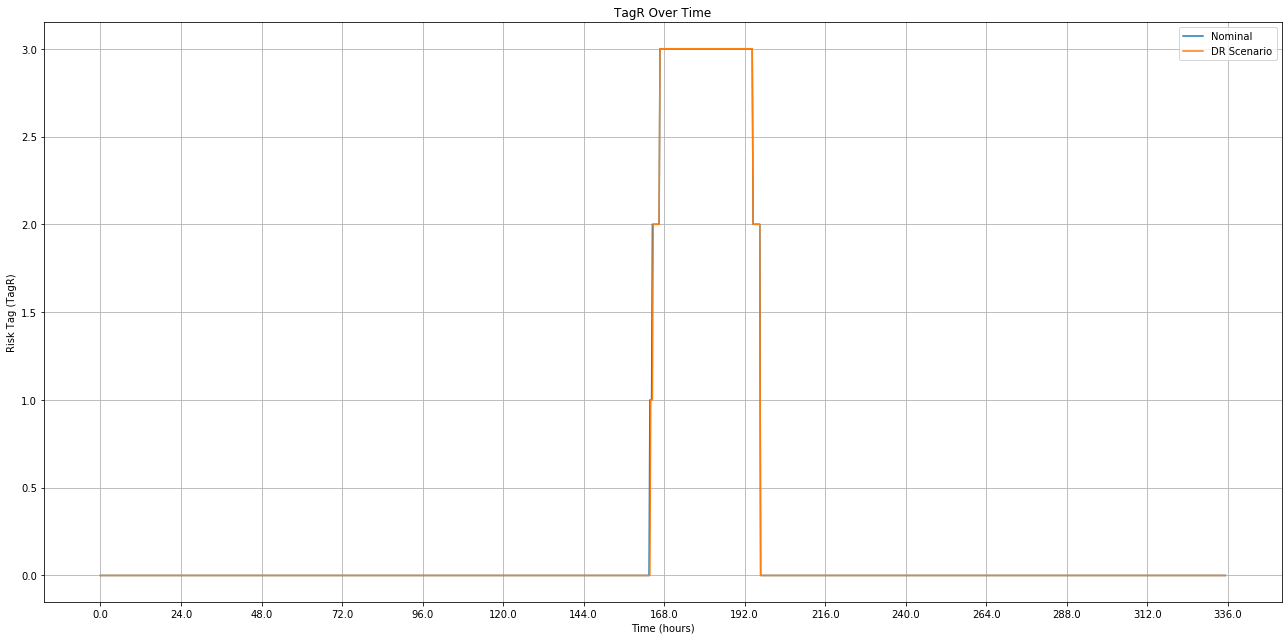

In [79]:
# Step 8: Plotting script
plt.figure(figsize=(18, 9))

plt.plot(nominal["tagR"], label="Nominal")
plt.plot(iteration["tagR"], label="DR Scenario")

# Set up time axis in hours
total_steps = 1344
time_step_hr = 0.25
xtick_interval = 96  # every 12 hours → 12 / 0.25 = 48 steps

plt.xticks(
    ticks=range(0, total_steps + 1, xtick_interval),
    labels=[f"{x * time_step_hr:.1f}" for x in range(0, total_steps + 1, xtick_interval)]
)

plt.xlabel("Time (hours)")
plt.ylabel("Risk Tag (TagR)")
plt.title("TagR Over Time")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

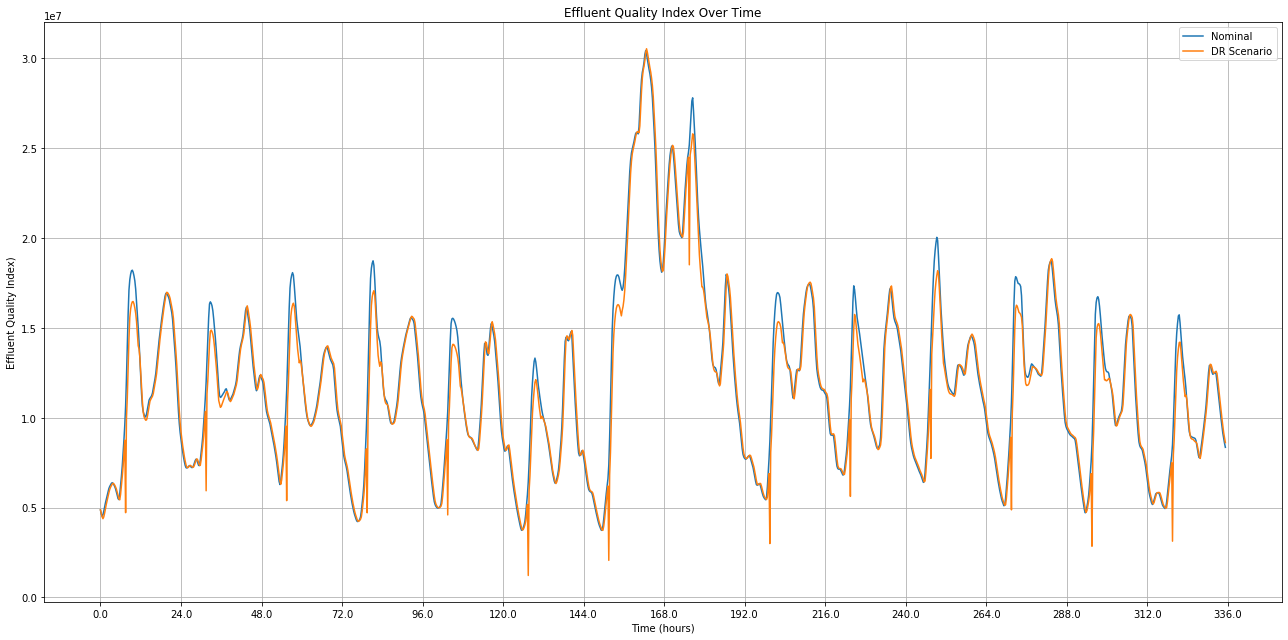

In [80]:
# Step 8: Plotting script
plt.figure(figsize=(18, 9))

plt.plot(nominal["EQIvecinst"], label="Nominal")
plt.plot(iteration["EQIvecinst"], label="DR Scenario")

# Set up time axis in hours
total_steps = 1344
time_step_hr = 0.25
xtick_interval = 96  # every 12 hours → 12 / 0.25 = 48 steps

plt.xticks(
    ticks=range(0, total_steps + 1, xtick_interval),
    labels=[f"{x * time_step_hr:.1f}" for x in range(0, total_steps + 1, xtick_interval)]
)

plt.xlabel("Time (hours)")
plt.ylabel("Effluent Quality Index)")
plt.title("Effluent Quality Index Over Time")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

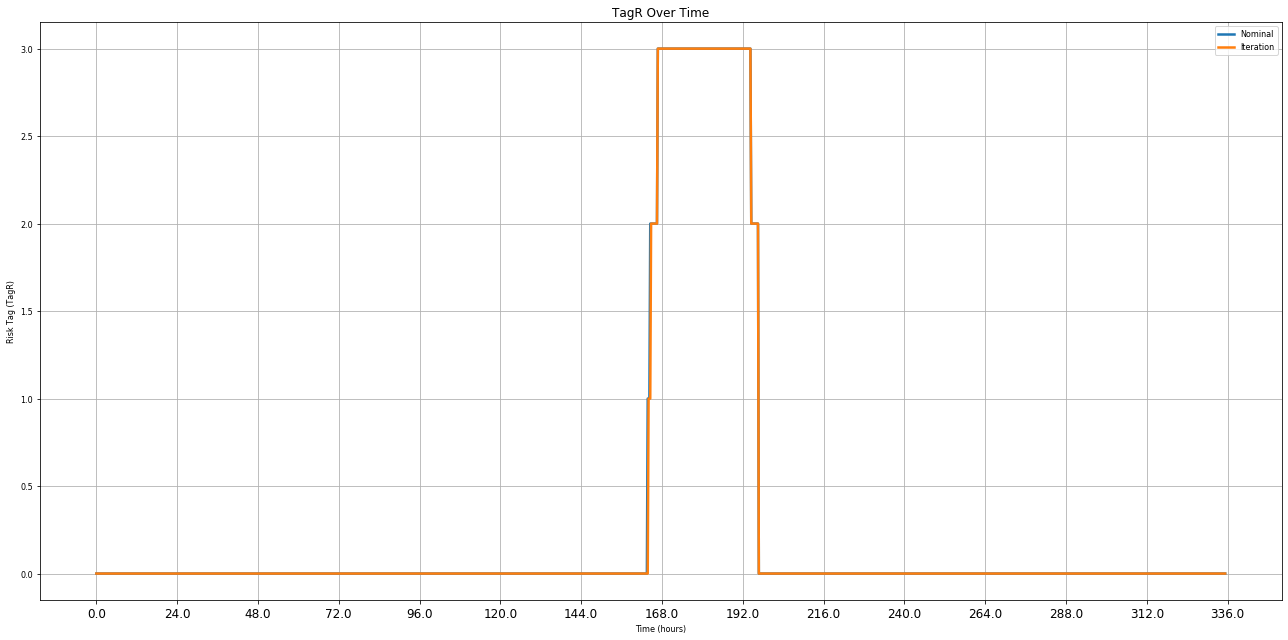

In [81]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 9))

# Thicker line width
plt.plot(nominal["tagR"], label="Nominal", linewidth=2.5)
plt.plot(iteration["tagR"], label="Iteration", linewidth=2.5)

# Time axis setup
total_steps = 1344
time_step_hr = 0.25
xtick_interval = 96  # every 12 hours

plt.xticks(
    ticks=range(0, total_steps + 1, xtick_interval),
    labels=[f"{x * time_step_hr:.1f}" for x in range(0, total_steps + 1, xtick_interval)],
    fontsize=12
)
plt.yticks(fontsize=8)

# Labels and title with larger font
plt.xlabel("Time (hours)", fontsize=8)
plt.ylabel("Risk Tag (TagR)", fontsize=8)
plt.title("TagR Over Time", fontsize=12)

# Larger legend font and enable grid
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()
